# 1. Imports

In [78]:
%load_ext autoreload

%reset -f
import sys
from os.path import dirname, join as pjoin
from os import listdir
sys.path.append('C:\\Users\\maryj\\OneDrive\\Desktop\\LAB') # set local directory
import numpy as np
import pickle
import random
#import xarray as xr
import pandas as pd
import warnings
from IPython import embed
import matplotlib.pyplot as plt
from collections import defaultdict

#import h5py
import scipy.io as sio
from scipy import stats
import statsmodels as sm # import statsmodels.api as 
from scipy.ndimage import uniform_filter1d

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Setup

In [79]:
# load .pkl file for when access to server is not available/ to save time
im_beh_pkl = pd.read_pickle( "imaging_beh_sessions_dataframe.pkl")
df = pd.DataFrame(im_beh_pkl)
df.head()

,Date,Group,Mouse,a,R,LR_Prob,Reaction_Time
0,221118,RSCATN,JL025,"[1, 1, 1, 1, 2, 1, 1, 3, 2, 1, 3, 1, 1, 1, 1, ...","[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[2.8923159999999997, 2.8556999999999997, 2.417..."
1,221122,RSCATN,JL025,"[1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, ...","[0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, ...","[2.495942, 2.971745, 2.942519, 2.820585, 2.385..."
2,221118,RSCATN,JL026,"[2, 1, 1, 1, 1, 1, 1, 2, 3, 2, 2, 2, 2, 4, 2, ...","[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.1302950000000003, 3.152237, 3.305116, 3.044..."
3,221120,RSCATN,JL026,"[2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, ...","[1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.3334740000000003, 0.411344, 3.146925, 2.889..."
4,221201,RSCATN,JL026,"[2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[3.095911, 2.992583, 2.99742, 2.51994999999999..."


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           118 non-null    object
 1   Group          118 non-null    object
 2   Mouse          118 non-null    object
 3   a              118 non-null    object
 4   R              118 non-null    object
 5   LR_Prob        118 non-null    object
 6   Reaction_Time  118 non-null    object
dtypes: object(7)
memory usage: 6.6+ KB


## 2.1 Info about the data
- `Date`, `Group`: Information about when the experiments are performed, and by who.   
- `Mouse`: the specific mouse tested. We can see we are working with 2 mice.   
- `a`: The action the mice took. The experiments start with a ready period, and when the mice are given an audio queue, they are prompted to start acting.     
    - "1": The mouse went right
    - "2": The mouse went left  
    - "3": Miss. The mouse was given the audio cue, but did not do anything.   
    - "4": Alarm. The mouse started acting before given the audio cue.    
For actions 3 and 4, the rewards are intuitively set to 0, as no meaningful trajectories are performed.  
- `LR_prob`: The reward is randomly placed either on the left or the right given a probability, unique to each session. Therefore, the list for each session contain the same value. 
- `R`: The reward. 0 indicates no reward, 1 indicates yes. 
- `Reaction_Time`: the time the mice take to make another decision to move. 

## 2.2 Encoding data
We use dictionaries so it's easier to access for analysis; also because all trial sequences are not the same length. 

In [81]:
# Dictionary to store encoded session data, now including reward probability
encoded_sessions = {}

for idx, row in df.iterrows():
    # Encode choices: 1 → 0 (left), 2 → 1 (right), others → np.nan
    choices = np.array(row['a'])
    choices_encoded = np.where(choices == 1, 0,
                       np.where(choices == 2, 1, np.nan))
    
    # Rewards and reaction times as numeric arrays
    rewards = np.array(row['R'], dtype=int)
    reaction_times = np.array(row['Reaction_Time'], dtype=float)
    
    # Reward probability: take first element since same across session
    reward_prob = float(row['LR_Prob'][0])
    
    # Store in dictionary by session index
    encoded_sessions[idx] = {
        'Mouse': row['Mouse'],
        'Date': row['Date'],
        'choices': choices_encoded,
        'rewards': rewards,
        'reaction_times': reaction_times,
        'LR_Prob': reward_prob
    }

# Example: access session 0
print("Choices:", encoded_sessions[0]['choices'][:10])
print("Rewards:", encoded_sessions[0]['rewards'][:10])
print("Reward probability:", encoded_sessions[0]['LR_Prob'])

Choices: [ 0.  0.  0.  0.  1.  0.  0. nan  1.  0.]
Rewards: [0 0 0 0 1 0 0 0 1 0]
Reward probability: 0.1


# 3. Data visualization

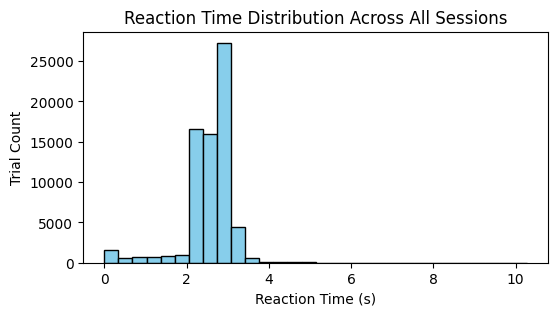

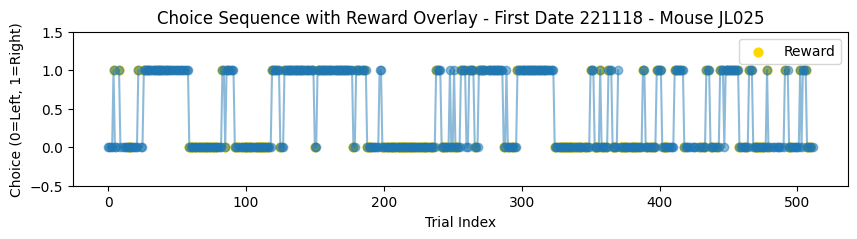

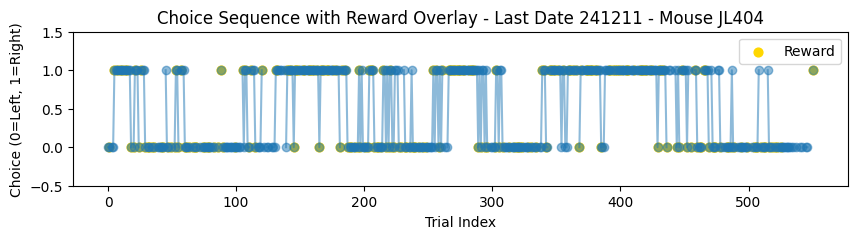

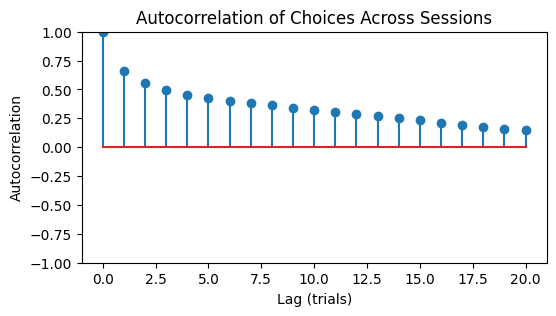

In [82]:
# ---------- Reaction Time Distribution (all sessions) ----------
all_rts = np.concatenate([encoded_sessions[idx]['reaction_times'] for idx in encoded_sessions])

plt.figure(figsize=(6,3))
plt.hist(all_rts, bins=30, color='skyblue', edgecolor='k')
plt.title('Reaction Time Distribution Across All Sessions')
plt.xlabel('Reaction Time (s)')
plt.ylabel('Trial Count')
plt.show()


# ---------- Choice Sequence with Reward Overlay (2 specific mice) ----------
# 1️⃣ Identify first and last training dates
all_dates = sorted({session['Date'] for session in encoded_sessions.values()})
first_date, last_date = all_dates[0], all_dates[-1]

# 2️⃣ Find first mouse for first date and first mouse for last date
first_mouse_session = None
last_mouse_session = None

for idx, session in encoded_sessions.items():
    if session['Date'] == first_date and first_mouse_session is None:
        first_mouse_session = session
    if session['Date'] == last_date and last_mouse_session is None:
        last_mouse_session = session

# 3️⃣ Plot for these 2 sessions
for session, label in zip([first_mouse_session, last_mouse_session], 
                          [f'First Date {first_date}', f'Last Date {last_date}']):
    choices = session['choices']
    rewards = session['rewards']
    
    plt.figure(figsize=(10,2))
    plt.plot(np.arange(len(choices)), choices, marker='o', linestyle='-', alpha=0.5)
    
    rewarded_trials = np.where(rewards==1)[0]
    plt.scatter(rewarded_trials, choices[rewarded_trials], color='gold', s=40, label='Reward')
    
    plt.title(f'Choice Sequence with Reward Overlay - {label} - Mouse {session["Mouse"]}')
    plt.xlabel('Trial Index')
    plt.ylabel('Choice (0=Left, 1=Right)')
    plt.ylim(-0.5, 1.5)
    plt.legend()
    plt.show()


# ---------- Autocorrelation Across All Sessions ----------
# Build "sessions x trials" matrix
max_len = max(len(encoded_sessions[idx]['choices']) for idx in encoded_sessions)
choice_matrix = []

for idx in encoded_sessions:
    choices = encoded_sessions[idx]['choices']
    padded = np.full(max_len, np.nan)
    padded[:len(choices)] = choices
    choice_matrix.append(padded)

choice_matrix = np.array(choice_matrix)  # shape: sessions x max_len

# Compute autocorrelation
lags = 20
acorr = []

for lag in range(lags+1):
    corr_vals = []
    for row in choice_matrix:
        if lag == 0:
            corr_vals.append(1.0)
        else:
            valid_idx = ~np.isnan(row[lag:]) & ~np.isnan(row[:-lag])
            if np.sum(valid_idx) > 1:
                corr = np.corrcoef(row[:-lag][valid_idx], row[lag:][valid_idx])[0,1]
                corr_vals.append(corr)
    acorr.append(np.nanmean(corr_vals))

plt.figure(figsize=(6,3))
plt.stem(range(lags+1), acorr, )
plt.title('Autocorrelation of Choices Across Sessions')
plt.xlabel('Lag (trials)')
plt.ylabel('Autocorrelation')
plt.ylim(-1,1)
plt.show()

In [100]:
df.head(1)['Reaction_Time']

0    [2.8923159999999997, 2.8556999999999997, 2.417...
Name: Reaction_Time, dtype: object

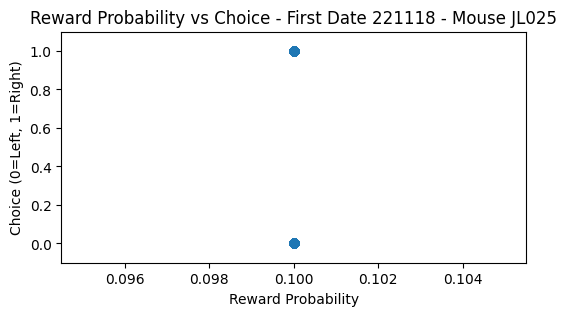

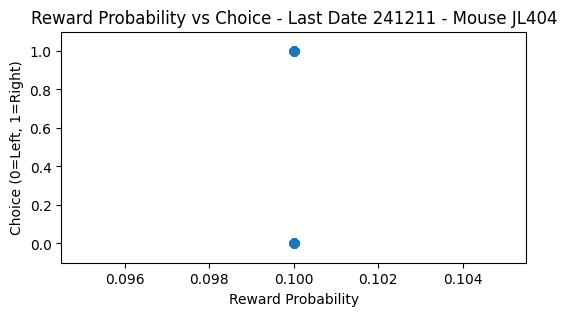

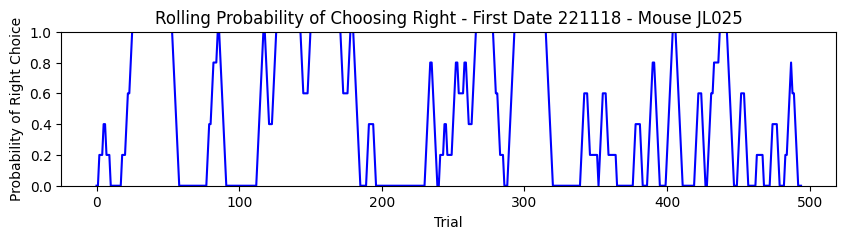

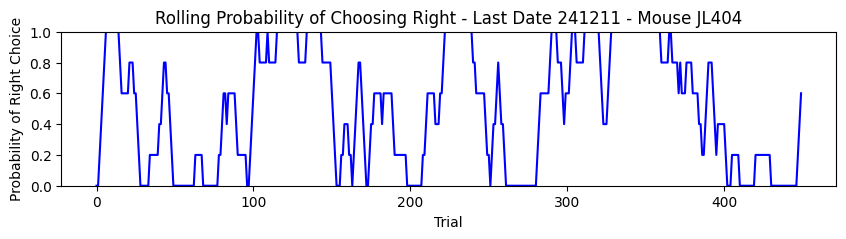

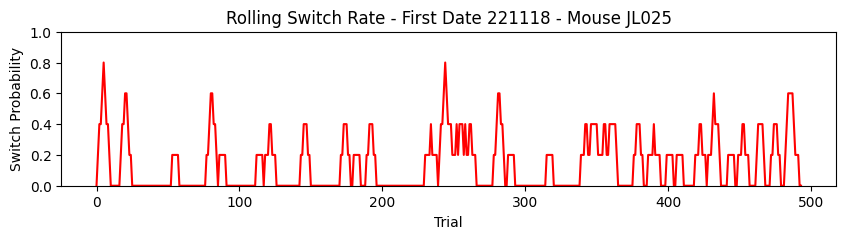

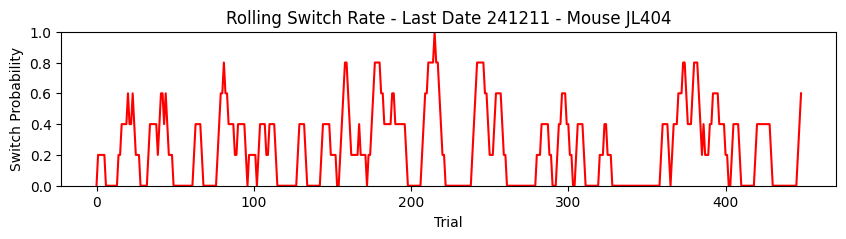

In [ ]:
sessions_to_plot = [first_mouse_session, last_mouse_session]
labels = [f'First Date {first_date}', f'Last Date {last_date}']

# ---------- 2️⃣ Reward Probability vs Choice ----------
for session, label in zip(sessions_to_plot, labels):
    choices = np.array(session['choices'], dtype=float)
    # session['choices'] is an array of length N
    reward_prob = np.full_like(session['choices'], fill_value=session['LR_Prob'], dtype=float)
    mask = ~np.isnan(choices) & ~np.isnan(reward_prob)        # ignore NaNs

    plt.figure(figsize=(6,3))
    plt.scatter(reward_prob[mask], choices[mask], alpha=0.5)
    plt.title(f'Reward Probability vs Choice - {label} - Mouse {session["Mouse"]}')
    plt.xlabel('Reward Probability')
    plt.ylabel('Choice (0=Left, 1=Right)')
    plt.ylim(-0.1, 1.1)
    plt.show()

# ---------- 3️⃣ Rolling Probability of Better Choice ----------
window = 5  # rolling window in trials

for session, label in zip(sessions_to_plot, labels):
    choices = np.array(session['choices'], dtype=float)
    mask = ~np.isnan(choices)
    clean_choices = choices[mask]

    rolling_choice = uniform_filter1d(clean_choices, size=window, mode='nearest')

    plt.figure(figsize=(10,2))
    plt.plot(np.arange(len(rolling_choice)), rolling_choice, color='blue')
    plt.title(f'Rolling Probability of Choosing Right - {label} - Mouse {session["Mouse"]}')
    plt.xlabel('Trial')
    plt.ylabel('Probability of Right Choice')
    plt.ylim(0,1)
    plt.show()

# ---------- 4️⃣ Rolling Switch Rate / Exploration ----------
for session, label in zip(sessions_to_plot, labels):
    choices = np.array(session['choices'], dtype=float)
    mask = ~np.isnan(choices)
    clean_choices = choices[mask]

    switches = np.abs(np.diff(clean_choices))  # 1 = switched, 0 = same
    rolling_switch = uniform_filter1d(switches, size=window, mode='nearest')

    plt.figure(figsize=(10,2))
    plt.plot(np.arange(len(rolling_switch)), rolling_switch, color='red')
    plt.title(f'Rolling Switch Rate - {label} - Mouse {session["Mouse"]}')
    plt.xlabel('Trial')
    plt.ylabel('Switch Probability')
    plt.ylim(0,1)
    plt.show()